# Stellar World Model — EDA
Quick inspection of raw FITS files and preprocessed NPZ files: structure, sample rows, and distributions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from pathlib import Path

REPO    = Path("../..")
LC_DIR  = REPO / "data" / "lc"
NPZ_DIR = REPO / "processed"

fits_files = sorted(LC_DIR.glob("*.fits"))
npz_files  = sorted(NPZ_DIR.glob("*.npz"))
print(f"FITS files : {len(fits_files)}")
print(f"NPZ  files : {len(npz_files)}")

FITS files : 85
NPZ  files : 85


---
## 1. FITS File Structure

In [ ]:
# Pick the first FITS file and inspect its HDU layout (analogous to df.info())
sample_fits = fits_files[0]
print(f"File: {sample_fits.name}\n")

with fits.open(sample_fits) as hdul:
    hdul.info()  # lists all HDUs: name, type, dimensions

In [ ]:
# Star metadata from the Primary Header (TIC ID, coordinates, stellar params)
with fits.open(sample_fits) as hdul:
    hdr = hdul[0].header

meta_keys = ["TICID", "SECTOR", "CAMERA", "CCD",
             "RA_OBJ", "DEC_OBJ", "TESSMAG", "TEFF", "LOGG", "MH"]
meta = {k: hdr.get(k, "N/A") for k in meta_keys}
pd.DataFrame.from_dict(meta, orient="index", columns=["Value"])

In [ ]:
# HDU[1] = LIGHTCURVE table: column names and formats (analogous to df.dtypes)
with fits.open(sample_fits) as hdul:
    cols   = hdul[1].columns
    n_rows = len(hdul[1].data)

print(f"Total rows: {n_rows:,}\n")
print("Column name & format:")
for c in cols:
    print(f"  {c.name:<24}  format={c.format}")

In [ ]:
# Load key columns into a DataFrame and inspect the first 10 rows (like df.head(10))
key_cols = ["TIME", "PDCSAP_FLUX", "PDCSAP_FLUX_ERR", "SAP_FLUX", "QUALITY"]

with fits.open(sample_fits) as hdul:
    tbl = hdul[1].data
    # FITS stores values in big-endian (>f4, >i4).
    # NumPy 2.x ufuncs reject non-native byte order, so we cast explicitly.
    df = pd.DataFrame({
        c: np.array(tbl[c], dtype=np.int32 if c == "QUALITY" else np.float64)
        for c in key_cols
    })

print("First 10 rows:")
display(df.head(10))
print("\nDescriptive statistics:")
display(df.describe())

In [ ]:
# QUALITY flag distribution (0 = clean, non-zero = flagged)
q = df["QUALITY"]
print(f"QUALITY==0 (clean): {(q==0).sum():>6,}  /  {len(q):,}  ({100*(q==0).mean():.1f}%)")
print("\nTop 10 non-zero QUALITY values:")
display(q[q != 0].value_counts().head(10).rename("count"))

---
## 2. Raw Light Curve — Before vs After Quality Filter

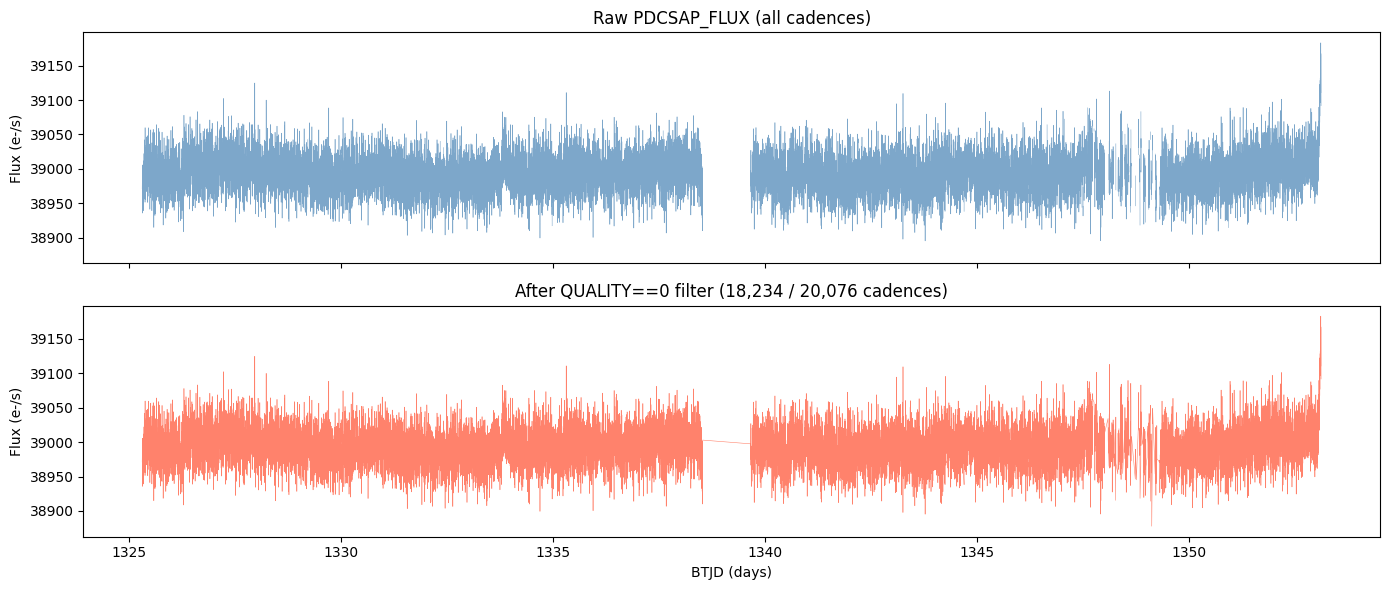

In [7]:
time = df["TIME"].values
flux = df["PDCSAP_FLUX"].values
good = (df["QUALITY"] == 0).values

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(time, flux, lw=0.4, color="steelblue", alpha=0.7)
axes[0].set_title("Raw PDCSAP_FLUX (all cadences)")
axes[0].set_ylabel("Flux (e-/s)")

axes[1].plot(time[good], flux[good], lw=0.4, color="tomato", alpha=0.8)
axes[1].set_title(f"After QUALITY==0 filter ({good.sum():,} / {len(good):,} cadences)")
axes[1].set_ylabel("Flux (e-/s)")
axes[1].set_xlabel("BTJD (days)")

plt.tight_layout()
plt.show()

---
## 3. Preprocessed NPZ Files

In [ ]:
# Inspect one NPZ file: keys, shapes, dtypes (analogous to df.info())
sample_npz = npz_files[0]
d = np.load(sample_npz)

print(f"File: {sample_npz.name}")
for k in d.files:
    arr = d[k]
    print(f"  key={k!r:<12}  shape={str(arr.shape):<18}  dtype={arr.dtype}")

In [ ]:
# Per-window statistics as a DataFrame (analogous to df.describe())
windows = d["windows"][:, :, 0]  # [N, 1024, 1] -> [N, 1024]

stats = pd.DataFrame({
    "window_idx" : np.arange(len(windows)),
    "mean"       : np.nanmean(windows, axis=1),
    "std"        : np.nanstd (windows, axis=1),
    "min"        : np.nanmin (windows, axis=1),
    "max"        : np.nanmax (windows, axis=1),
    "nan_frac_%" : np.isnan(windows).mean(axis=1) * 100,
})

print(f"{len(stats)} windows total — first 10:")
display(stats.head(10))
print("\nOverall statistics:")
display(stats.describe())

In [ ]:
# Plot the first 6 MAD-normalised windows
t_hr = np.arange(1024) * 2 / 60  # 2-min cadence -> hours

fig, axes = plt.subplots(2, 3, figsize=(14, 5), sharey=True)
for i, ax in enumerate(axes.flat):
    if i >= len(windows):
        ax.axis("off")
        continue
    ax.plot(t_hr, windows[i], lw=0.8, color="steelblue")
    ax.set_title(f"Window {i}")
    ax.set_xlabel("hours")
    ax.set_ylabel("MAD-norm flux")

fig.suptitle(f"{sample_npz.name} — normalised windows", fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Global Statistics Across All Stars

In [ ]:
# Summarise every NPZ file: windows per star, NaN fraction, flux variability
rows = []
for fp in npz_files:
    d = np.load(fp)
    w = d["windows"][:, :, 0]
    rows.append({
        "tic_id"        : int(d["tic_id"]),
        "sector"        : int(d["sector"]),
        "n_windows"     : len(w),
        "nan_frac_%"    : float(np.isnan(w).mean() * 100),
        "flux_std_mean" : float(np.nanstd(w)),
    })

summary = pd.DataFrame(rows).sort_values("tic_id").reset_index(drop=True)
print(f"{len(summary)} stars total")
display(summary.head(10))
print()
display(summary[["n_windows", "nan_frac_%", "flux_std_mean"]].describe())

In [ ]:
# Distribution plots: window count / NaN fraction / flux variability
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(summary["n_windows"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Windows per star")
axes[0].set_title("Window count distribution")

axes[1].hist(summary["nan_frac_%"], bins=20, color="tomato", edgecolor="white")
axes[1].set_xlabel("NaN fraction (%)")
axes[1].set_title("NaN fraction distribution")

axes[2].hist(summary["flux_std_mean"], bins=20, color="seagreen", edgecolor="white")
axes[2].set_xlabel("Std of normalised flux")
axes[2].set_title("Flux variability distribution")

plt.tight_layout()
plt.show()